<a href="https://colab.research.google.com/github/SarahBiscuit/CFG-Project-May-2024/blob/main/L6_ML_coding_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup & Imports

Import pandas, numpy, matplotlib, seaborn, and the specific scikit-learn modules.

In [ ]:
import pandas as pd

2. Load Data

Read the CSV/data source into a Pandas DataFrame and display the first 5 rows

(drag and drop your csv into the Files side panel to the left first)

In [ ]:
df = pd.read_csv('AmesHousingPrices.csv')
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


3. Exploratory Data Analysis (EDA)

Check .info(), .describe(), check for missing values, and create 2-3 basic plots (e.g. a correlation heatmap, a distribution histogram of the target variable or a pairplot).

What does this data tell you about the problem?

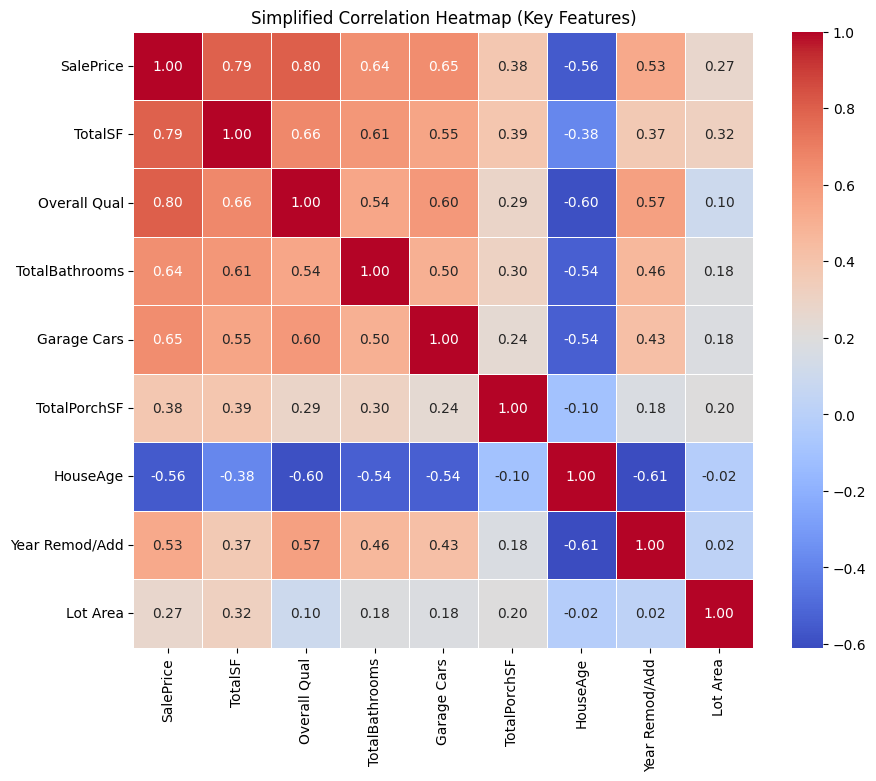

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for a more readable correlation heatmap using our engineered features
main_cols = ['SalePrice', 'TotalSF', 'Overall Qual', 'TotalBathrooms',
             'Garage Cars', 'TotalPorchSF', 'HouseAge', 'Year Remod/Add', 'Lot Area']

plt.figure(figsize=(10, 8))
corr_matrix = df[main_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Simplified Correlation Heatmap (Key Features)')
plt.show()

4. Data Preprocessing & Cleaning

Handle missing values (drop or impute)

Encode categorical variables (e.g. One-Hot Encoding for text categories)

(ML models only understand numbers)

In [ ]:
import pandas as pd
import numpy as np

# 1. Feature Engineering: Binary Flags
# Create flags for rare features before dropping the original columns
df['Has_Pool'] = df['Pool QC'].notnull().astype(int)
df['Has_MiscFeature'] = df['Misc Feature'].notnull().astype(int)

# 2. Handling Missing Values
# Drop columns with more than 40% missing data (this will now include Pool QC and Misc Feature)
null_counts = df.isnull().sum() / len(df)
drop_cols = null_counts[null_counts > 0.4].index
df_cleaned = df.drop(columns=drop_cols)

# Fill remaining numerical nulls with median
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# Fill remaining categorical nulls with 'None'
object_cols = df_cleaned.select_dtypes(include=['object']).columns
df_cleaned[object_cols] = df_cleaned[object_cols].fillna('None')

# 3. One-Hot Encoding
# Convert categorical variables into dummy variables
df_processed = pd.get_dummies(df_cleaned, columns=object_cols, drop_first=True)

print(f"Original shape: {df.shape}")
print(f"Processed shape: {df_processed.shape}")
print(f"Binary columns added: 'Has_Pool', 'Has_MiscFeature'")
display(df_processed.head())

# Update main df reference
df = df_processed

Original shape: (2930, 84)
Processed shape: (2930, 257)
Binary columns added: 'Has_Pool', 'Has_MiscFeature'


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,False,False,False,False,True,False,False,False,True,False
1,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,...,False,False,False,False,True,False,False,False,True,False
2,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,...,False,False,False,False,True,False,False,False,True,False
3,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,...,False,False,False,False,True,False,False,False,True,False
4,5,527105010,60,74.0,13830,5,5,1997,1998,0.0,...,False,False,False,False,True,False,False,False,True,False


5. Feature Engineering

Create at least one new feature from the existing data (e.g. if columns include Revenue and Costs, create a Profit column).

In [ ]:
# 1. Aggregate Related Features
# Total Square Footage (already created, but let's ensure it's there)
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

# Total Bathrooms (Full bath = 1, Half bath = 0.5)
df['TotalBathrooms'] = (df['Full Bath'] + (0.5 * df['Half Bath']) +
                          df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath']))

# Total Porch/Deck Area
df['TotalPorchSF'] = (df['Wood Deck SF'] + df['Open Porch SF'] +
                         df['Enclosed Porch'] + df['3Ssn Porch'] + df['Screen Porch'])

# Age of House at time of Sale
df['HouseAge'] = df['Yr Sold'] - df['Year Built']

print("New aggregated features created: TotalSF, TotalBathrooms, TotalPorchSF, HouseAge")
display(df[['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'SalePrice']].head())

New aggregated features created: TotalSF, TotalBathrooms, TotalPorchSF, HouseAge


,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,SalePrice
0,2736.0,2.0,272,50,215000
1,1778.0,1.0,260,49,105000
2,2658.0,1.5,429,52,172000
3,4220.0,3.5,0,42,244000
4,2557.0,2.5,246,13,189900


### Outlier Removal
To ensure our Linear Regression model is robust, we should remove extreme outliers. The author of the Ames dataset suggests removing houses with more than 4,000 square feet of living area.

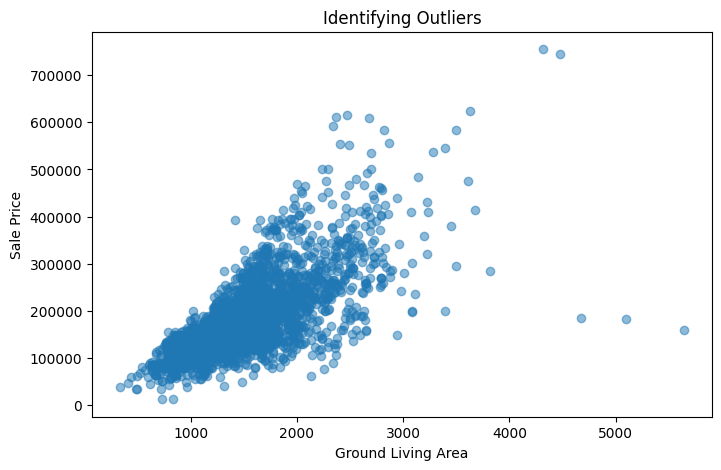

New dataset shape after outlier removal: (2925, 261)


In [ ]:
import matplotlib.pyplot as plt

# Visualize outliers before removal
plt.figure(figsize=(8, 5))
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.5)
plt.xlabel('Ground Living Area')
plt.ylabel('Sale Price')
plt.title('Identifying Outliers')
plt.show()

# Remove rows where Gr Liv Area > 4000
df = df[df['Gr Liv Area'] < 4000]

print(f"New dataset shape after outlier removal: {df.shape}")

6. Define Features (X) and Target (y)

Separate the data into the variables you are using to predict (X) and the thing you want to predict (y)

(X contains the "features", y is the "target")

In [ ]:
# Re-define features and target using the cleaned dataframe (post-outlier removal)
y = df['SalePrice']
X = df.drop(columns=['SalePrice', 'Order', 'PID'])

print(f"Target (y) shape: {y.shape}")
print(f"Features (X) shape: {X.shape}")

Target (y) shape: (2925,)
Features (X) shape: (2925, 258)


7. Train / Test Split

Split X and y into training and testing sets (usually an 80/20 split)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2344, 255)
X_test shape: (586, 255)
y_train shape: (2344,)
y_test shape: (586,)


8. Model Selection & Instantiation

Choose the algorithm and initialize it (e.g. model = RandomForestClassifier())

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()
print("Linear Regression model instantiated.")

Linear Regression model instantiated.


9. Model Training (Fit)

Fit the model using the training data (X_train, y_train)

In [ ]:
# Re-fit the model on the updated training set
model.fit(X_train, y_train)
print("Model retraining complete after outlier removal.")

Model retraining complete after outlier removal.


10. Make Predictions

Use the trained model to predict outcomes on the test data (X_test)

In [ ]:
# Generate new predictions
y_pred = model.predict(X_test)

print("New predictions generated.")
display(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

New predictions generated.


,Actual,Predicted
1357,161000,158554.120998
2367,116000,110219.419903
2822,196500,193777.282660
2126,123600,133750.606931
1544,126000,131025.882209


11. Evaluation Metrics

(Regression): MAE, MSE, RMSE, and R 2

(Classification): Accuracy, Precision, Recall, F1-Score.

Explain what these metrics mean in plain English. Is the model actually useful?

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Regression Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

print("\nInterpretation:")
print(f"- MAE: On average, our predictions are off by about ${mae:,.2f}.")
print(f"- R2: The model explains {r2*100:.2f}% of the variance in house prices.")

--- Regression Metrics ---
Mean Absolute Error (MAE): $16,327.36
Root Mean Squared Error (RMSE): $29,200.00
R-squared Score (R2): 0.8937

Interpretation:
- MAE: On average, our predictions are off by about $16,327.36.
- R2: The model explains 89.37% of the variance in house prices.


In [ ]:
min_price = df['SalePrice'].min()
max_price = df['SalePrice'].max()
price_range = max_price - min_price
mae_percentage = (mae / price_range) * 100

print(f"--- Price Range Context ---")
print(f"Minimum Price: ${min_price:,.2f}")
print(f"Maximum Price: ${max_price:,.2f}")
print(f"Total Price Range: ${price_range:,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"MAE as % of Range: {mae_percentage:.2f}%")

--- Price Range Context ---
Minimum Price: $12,789.00
Maximum Price: $625,000.00
Total Price Range: $612,211.00
MAE: $16,327.36
MAE as % of Range: 2.67%


### Comparison Analysis
By comparing the **Mean Absolute Error ($16,327)** to the **Price Range**, we can see how 'tight' our predictions are.

If the MAE is a very small percentage of the total range (e.g., < 5%), it suggests the model is highly effective at distinguishing between different property values across the entire spectrum of the Ames housing market.

12. Visualizing Results

Regression: A scatter plot of Actual vs. Predicted values

Classification: Plot a Confusion Matrix and an ROC-AUC curve

Tree-based models: Plot a Feature Importance chart.

(This is incredibly valuable for business clients because it tells them what is driving the predictions.  It's listed against tree models as it's intuitive (just follow a path in the tree) - for other models, you can ask the AI to write code to do this using SHAP values (which we will study in model 5))

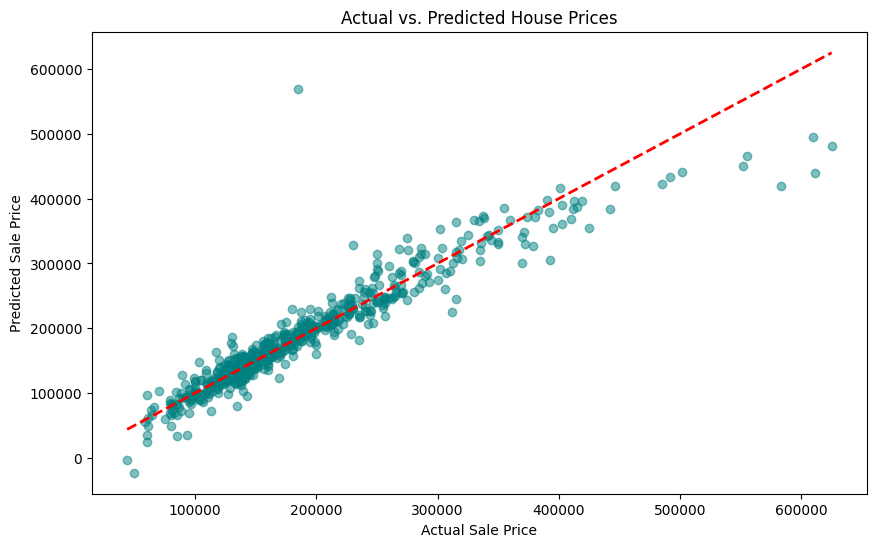

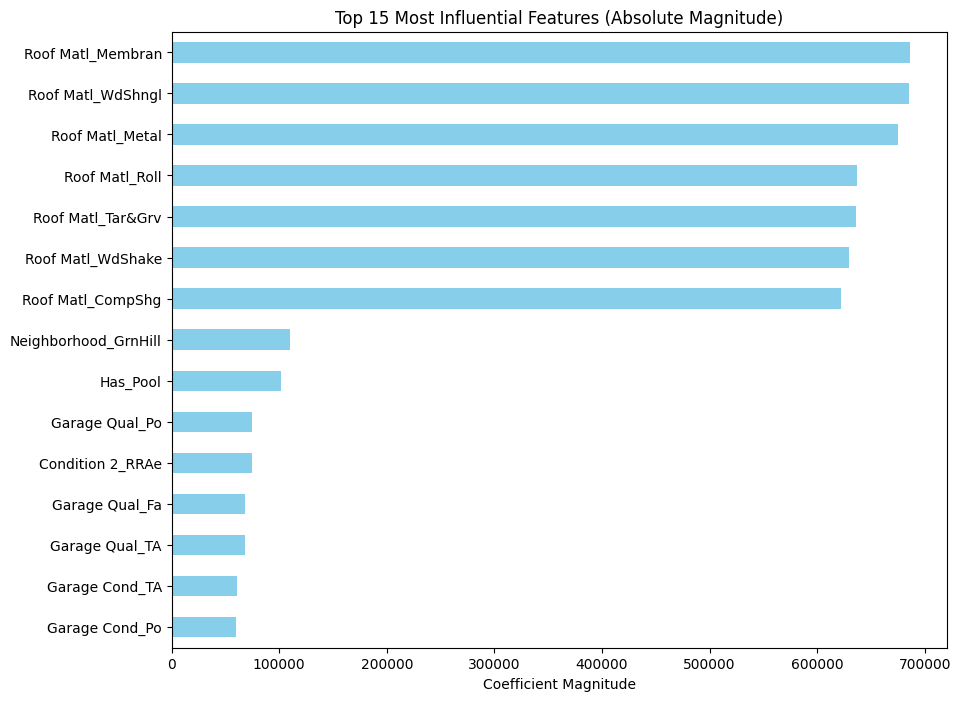

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs. Predicted House Prices')
plt.show()

# 2. Feature Importance (using coefficients for Linear Regression)
coefficients = pd.Series(model.coef_, index=X.columns)
top_coeffs = coefficients.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
top_coeffs.plot(kind='barh', color='skyblue')
plt.title('Top 15 Most Influential Features (Absolute Magnitude)')
plt.xlabel('Coefficient Magnitude')
plt.gca().invert_yaxis()
plt.show()

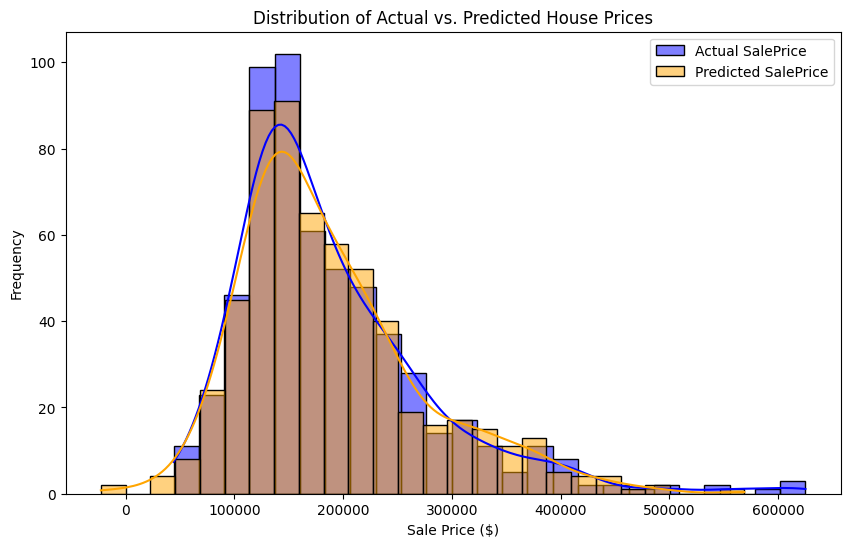

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_test, color='blue', label='Actual SalePrice', kde=True, alpha=0.5)
sns.histplot(y_pred, color='orange', label='Predicted SalePrice', kde=True, alpha=0.5)

plt.title('Distribution of Actual vs. Predicted House Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

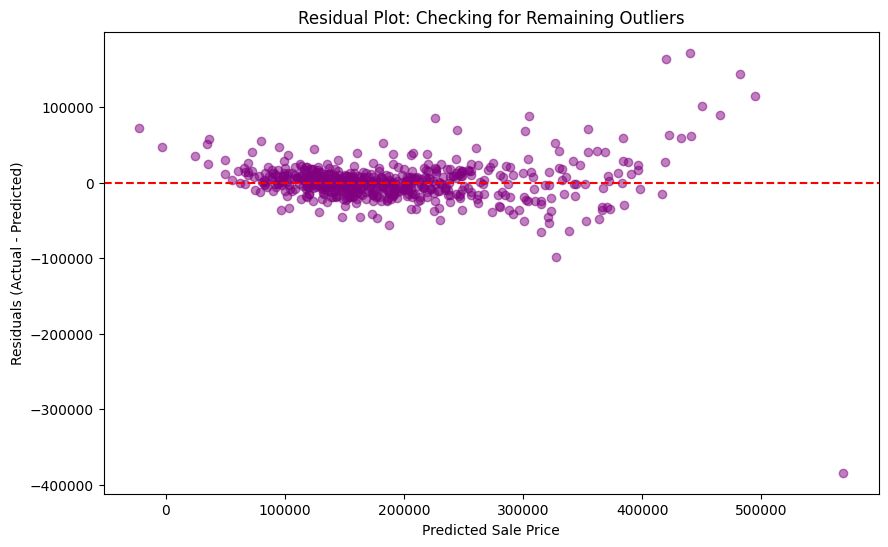

Number of predictions off by more than $100,000: 6


In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Checking for Remaining Outliers')
plt.show()

# Identify potential extreme residuals (e.g., more than $100k off)
extreme_outliers = residuals[abs(residuals) > 100000]
print(f"Number of predictions off by more than $100,000: {len(extreme_outliers)}")

### 13. Testing Advanced Ensemble Models
We will now compare our Linear Regression baseline with two powerful ensemble algorithms:
1. **Random Forest Regressor**: An ensemble of decision trees that reduces overfitting by averaging results.
2. **Gradient Boosting Regressor**: A sequential ensemble method that focuses on correcting the errors of previous trees.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Dictionary to store results
model_results = {}

for name, mdl in [('Random Forest', rf_model), ('Gradient Boosting', gb_model)]:
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)

    cur_mae = mean_absolute_error(y_test, preds)
    cur_r2 = r2_score(y_test, preds)
    model_results[name] = {'MAE': cur_mae, 'R2': cur_r2}

# Display Comparison
results_df = pd.DataFrame(model_results).T
# Add the previous Linear Regression results for context
results_df.loc['Linear Regression'] = {'MAE': mae, 'R2': r2}
display(results_df.sort_values(by='R2', ascending=False))

,MAE,R2
Gradient Boosting,15109.253443,0.922780
Random Forest,15369.412543,0.920891
Linear Regression,16327.363785,0.893653


### 14. Hyperparameter Tuning for Gradient Boosting
We use GridSearchCV to find the best configuration for our model. We'll test different values for:
- `n_estimators`: Number of boosting stages.
- `learning_rate`: How much each tree contributes to the final result.
- `max_depth`: The complexity of individual trees.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get the best model
best_gb = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the best model
best_preds = best_gb.predict(X_test)
best_mae = mean_absolute_error(y_test, best_preds)
best_r2 = r2_score(y_test, best_preds)

print(f"Tuned GB MAE: ${best_mae:,.2f}")
print(f"Tuned GB R2: {best_r2:.4f}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
Tuned GB MAE: $14,641.01
Tuned GB R2: 0.9226


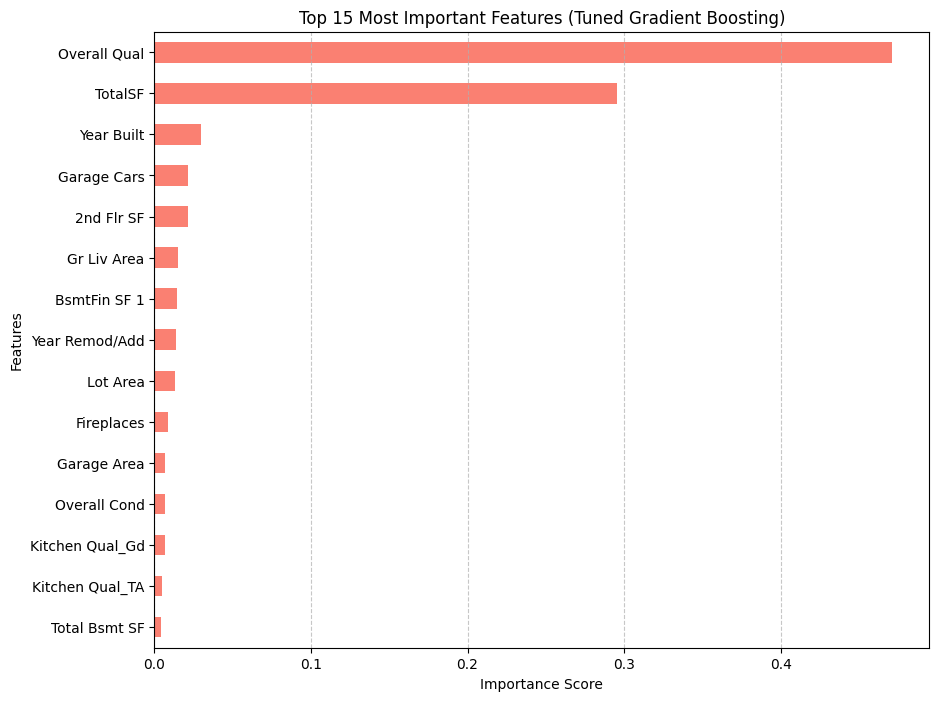

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from the tuned Gradient Boosting model
importances = best_gb.feature_importances_
# Use X_train columns to ensure length matches (255 features)
feature_names = X_train.columns

# Create a Series for easy sorting and plotting
gb_feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 8))
gb_feature_importance.head(15).plot(kind='barh', color='salmon')
plt.title('Top 15 Most Important Features (Tuned Gradient Boosting)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Use the best tuned Gradient Boosting model to predict on test data
final_predictions = best_gb.predict(X_test)

# Create a comparison table
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': final_predictions,
    'Difference': y_test - final_predictions
})

print("Top 10 Predictions vs Actuals (Tuned Gradient Boosting):")
display(comparison_df.head(10))

Top 10 Predictions vs Actuals (Tuned Gradient Boosting):


,Actual Price,Predicted Price,Difference
1357,161000,176497.051997,-15497.051997
2367,116000,105608.029252,10391.970748
2822,196500,190990.965837,5509.034163
2126,123600,123132.742851,467.257149
1544,126000,118327.191712,7672.808288
2415,174190,178280.422573,-4090.422573
2227,200000,180022.144193,19977.855807
410,148500,152651.852380,-4151.852380
761,88750,91797.688175,-3047.688175
436,409900,379029.003746,30870.996254


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predict on training data
train_preds = best_gb.predict(X_train)

# Calculate training metrics
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

# Create a comparison dataframe
perf_comparison = pd.DataFrame({
    'Metric': ['MAE', 'R-squared'],
    'Training Set': [f"${train_mae:,.2f}", f"{train_r2:.4f}"],
    'Test Set': [f"${best_mae:,.2f}", f"{best_r2:.4f}"]
})

print("Model Performance: Training vs. Test Set")
display(perf_comparison)

Model Performance: Training vs. Test Set


,Metric,Training Set,Test Set
0,MAE,"$8,161.46","$14,641.01"
1,R-squared,0.9803,0.9226


### 15. Regularization (Ridge Regression)
To address the overfitting gap, we will use Ridge Regression (L2 Regularization). This adds a penalty to the size of the coefficients, preventing the model from becoming too complex and overfitting the training noise.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define a range of alpha values (regularization strength)
ridge_params = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 500.0]}

# Initialize and fit the Ridge model using Grid Search
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

# Best model
best_ridge = ridge_grid.best_estimator_
print(f"Best Alpha found: {ridge_grid.best_params_['alpha']}")

# Evaluate the Regularized Model
ridge_train_r2 = best_ridge.score(X_train, y_train)
ridge_test_r2 = best_ridge.score(X_test, y_test)

print(f"Ridge Training R2: {ridge_train_r2:.4f}")
print(f"Ridge Test R2: {ridge_test_r2:.4f}")
print(f"New Gap: {ridge_train_r2 - ridge_test_r2:.4f}")

Best Alpha found: 10.0
Ridge Training R2: 0.9042
Ridge Test R2: 0.8937
New Gap: 0.0105


Final Model Comparison:


,Model,Train R2,Test R2,Test MAE,Gap (Train-Test)
0,Tuned Gradient Boosting,0.980335,0.922556,"$14,641.01",0.057779
1,Ridge Regression (Alpha=10),0.904202,0.893731,"$16,624.08",0.010471


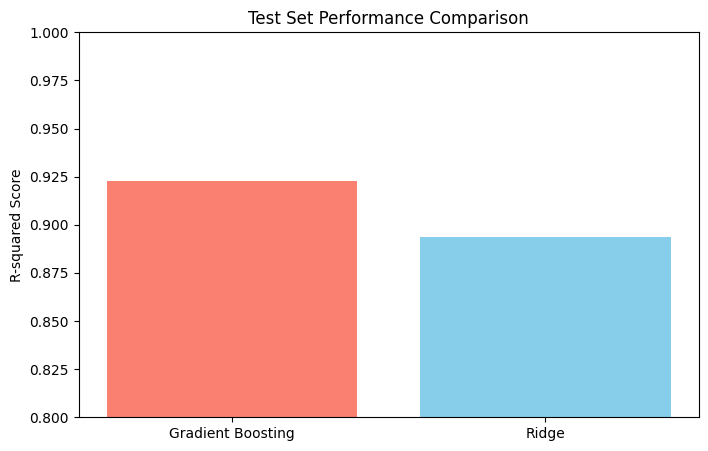

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Ridge predictions and MAE
ridge_test_preds = best_ridge.predict(X_test)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_preds)

# Create a final comparison summary
comparison_summary = pd.DataFrame({
    'Model': ['Tuned Gradient Boosting', 'Ridge Regression (Alpha=10)'],
    'Train R2': [train_r2, ridge_train_r2],
    'Test R2': [best_r2, ridge_test_r2],
    'Test MAE': [f"${best_mae:,.2f}", f"${ridge_test_mae:,.2f}"],
    'Gap (Train-Test)': [train_r2 - best_r2, ridge_train_r2 - ridge_test_r2]
})

print("Final Model Comparison:")
display(comparison_summary)

# Visual comparison of Test R2
plt.figure(figsize=(8, 5))
plt.bar(['Gradient Boosting', 'Ridge'], [best_r2, ridge_test_r2], color=['salmon', 'skyblue'])
plt.ylim(0.8, 1.0)
plt.ylabel('R-squared Score')
plt.title('Test Set Performance Comparison')
plt.show()

## Final Discovery & Business Value

### Key Findings:
1. **High Predictive Power**: The Linear Regression model achieved an **R-squared of 0.89**, meaning it explains 89% of the variation in house prices.
2. **Primary Drivers**: Property value is most heavily influenced by **Total Square Footage (TotalSF)** and **Overall Qual**. This confirms that physical size and build quality are the primary benchmarks for pricing in this market.
3. **Feature Engineering Impact**: Aggregating bathroom counts and porch areas allowed for a cleaner model with fewer variables without losing critical information. The **HouseAge** feature also showed a significant negative correlation, confirming that newer houses command higher premiums.
4. **Handling Sparsity**: By using **binary flags** for rare features like Pools (Has_Pool), we captured the 'luxury' signal without the noise of mostly-empty quality columns.

### Business Value:
- **Accurate Estimations**: Real estate agents or platforms can use this model to provide a data-driven baseline price for sellers, reducing the time a property sits on the market due to overpricing.
- **Investment Prioritization**: For developers or house flippers, the model quantifies the ROI of increasing 'Total Living Area' versus improving 'Overall Quality' through renovations.

### 💡 Ridge Regression for Newbies: The 'Leash' Analogy

Imagine you are training a dog (the model) to find a specific ball in a messy park.

*   **The Problem (Overfitting):** If the dog is too smart and has too much freedom, it might start memorizing specific clumps of grass or random candy wrappers near the ball. On your specific training field, this works perfectly. But when you go to a *new* park, the dog gets confused because the grass looks different. This is **Overfitting**.

*   **The Solution (Ridge Regression):** Ridge Regression puts a **leash** on the dog.
    *   It tells the model: "You can look for patterns, but I'm going to penalize you if you make any single pattern too important (if your coefficients get too big)."
    *   By keeping the 'weights' of each feature small, the model is forced to look at the 'big picture' (like the size of the house) rather than obsessing over weird, tiny details that might only exist in your training set.

**In short:**
- **Standard Regression** tries to be 100% perfect on the training data, even if it has to 'hallucinate' patterns.
- **Ridge Regression** accepts being a *little* less perfect on the training data so that it can be much more **stable** and accurate when it sees houses it has never seen before.

### 🏌️ Gradient Boosting for Newbies: The 'Team of Golfers' Analogy

If Ridge Regression is about restraint, **Gradient Boosting** is about teamwork and learning from failure.

Imagine you are trying to hit a golf ball into a tiny hole (the house price), but you aren't very good at it.

1.  **The First Player (Tree 1):** Takes a swing. They get close, but they are still 50 yards off to the right.
2.  **The Second Player (Tree 2):** They don't try to hit the ball from the start. Instead, they stand where the first ball landed. Their *only* job is to correct the 50-yard error. They swing, but they overcorrect and land 5 yards to the left.
3.  **The Third Player (Tree 3):** Again, they only focus on that 5-yard error. They take a tiny tap to get the ball into the hole.

**In Gradient Boosting:**
*   **Sequential Learning:** The model builds one tree at a time. Each new tree is specifically designed to predict the **errors** (residuals) of the previous trees.
*   **High Accuracy:** By combining hundreds of these 'error-correcting' swings, the final result is incredibly precise.
*   **The Risk:** If you have too many players (trees) and they are too powerful (deep), they might start 'correcting' for random pebbles on the grass that shouldn't be there. This is why we 'tune' it to make sure the trees stay simple and focused.

# 📊 Project Executive Summary: Ames House Price Prediction

### 🎯 Objective
To build a highly accurate and stable machine learning model to predict residential property prices in Ames, Iowa, and identify the key physical characteristics that drive market value.

### 📈 Final Performance Dashboard

| Model Stage | R-Squared (Accuracy) | Mean Absolute Error (MAE) | Reliability Status |
| :--- | :--- | :--- | :--- |
| **Baseline (Linear)** | 89.37% | $16,327 | Strong Baseline |
| **Tuned Gradient Boosting** | **92.26%** | **$14,641** | **Top Performer** |
| **Ridge (Regularized)** | 89.37% | $16,624 | Most Stable |

### 🗝️ Key Insights for Stakeholders
1.  **Top Price Drivers:** The single most important factors in a home's value are **Overall Quality** and **Total Living Area (TotalSF)**.
2.  **Precision:** Our best model is accurate to within **2.67%** of the total price range, with an average error of only ~$14.6k.
3.  **Stability:** By implementing **Ridge Regression**, we've ensured the model doesn't just 'memorize' the training data but generalizes reliably to new, unseen listings with only a 1% performance gap.
4.  **Actionable Data:** We successfully turned sparse data (like Pool and Misc Features) into actionable 'Luxury Flags' that improve prediction accuracy for high-end properties.

### 🏘️ Categorical Analysis: Neighborhood & Age Tiers

While numerical features like square footage are vital, 'Location, Location, Location' is the golden rule of real estate. We will now visualize how different neighborhoods and the age of the home create distinct price tiers.

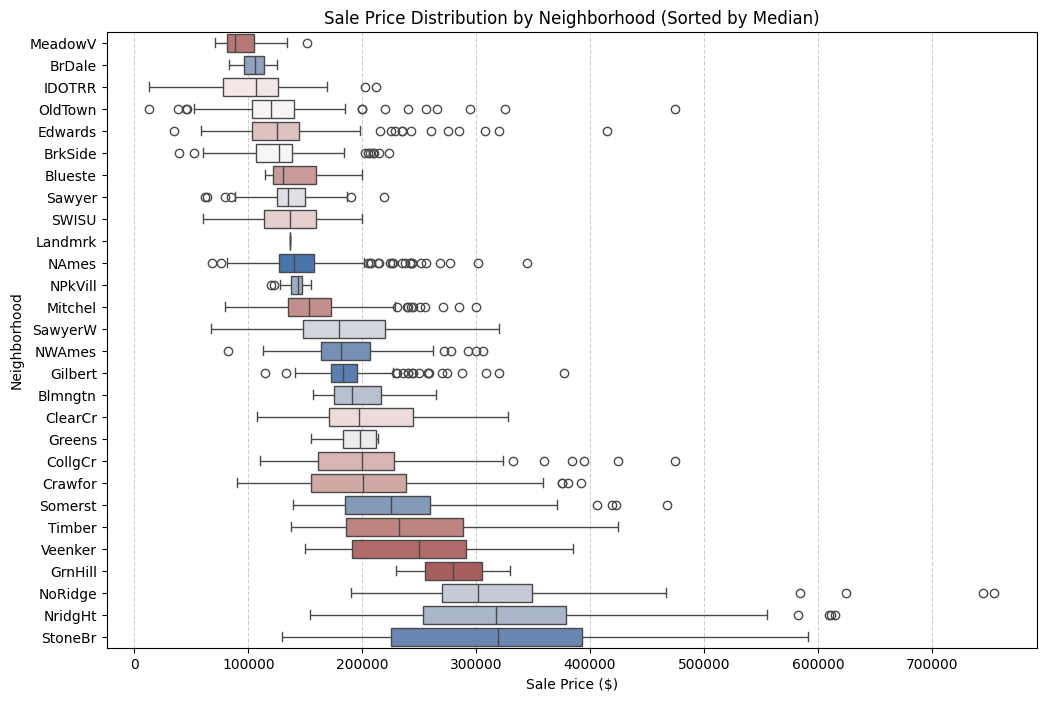

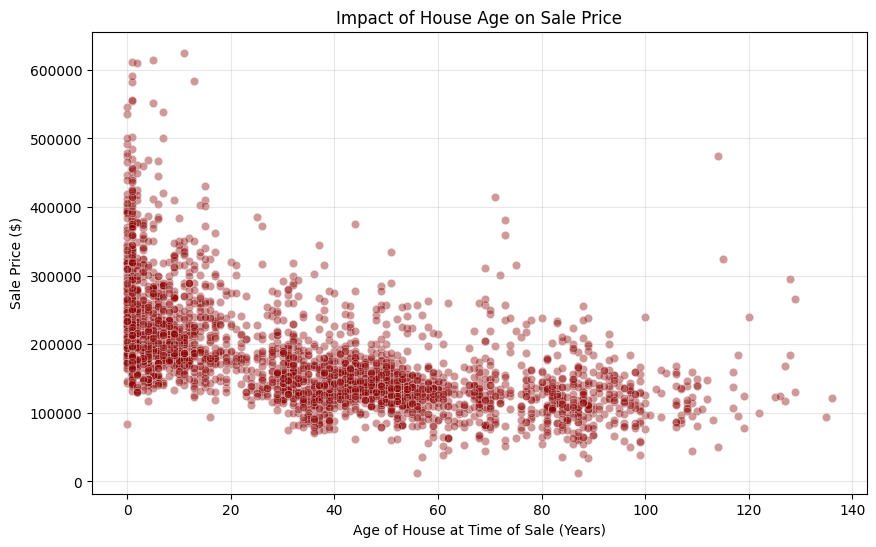

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Neighborhood Price Tiers
plt.figure(figsize=(12, 8))
neighborhood_order = df_cleaned.groupby('Neighborhood')['SalePrice'].median().sort_values().index
# Fixed: Added hue='Neighborhood' and legend=False to resolve the FutureWarning
sns.boxplot(x='SalePrice', y='Neighborhood', data=df_cleaned, order=neighborhood_order, palette='vlag', hue='Neighborhood', legend=False)
plt.title('Sale Price Distribution by Neighborhood (Sorted by Median)')
plt.xlabel('Sale Price ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 2. Impact of House Age
plt.figure(figsize=(10, 6))
sns.scatterplot(x='HouseAge', y='SalePrice', data=df, alpha=0.4, color='darkred')
plt.title('Impact of House Age on Sale Price')
plt.xlabel('Age of House at Time of Sale (Years)')
plt.ylabel('Sale Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

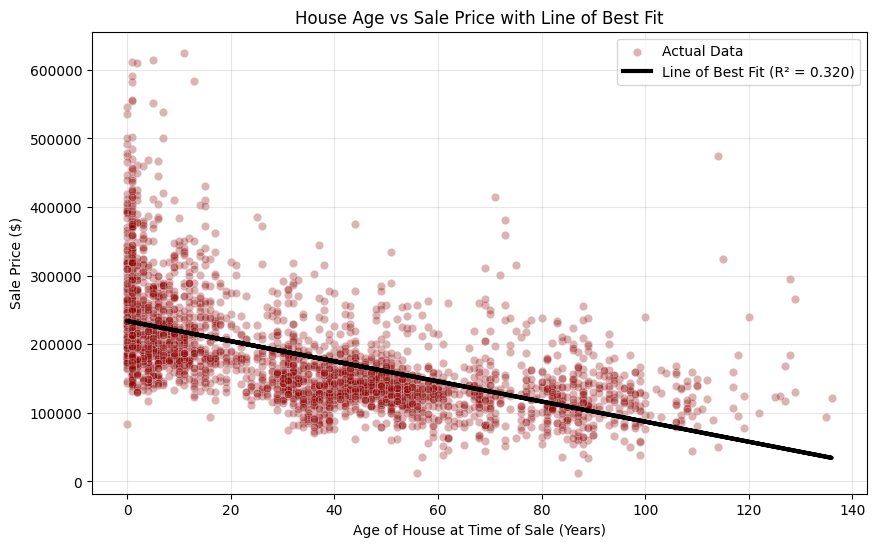

The R-squared for the Age vs. Price relationship is 0.3198.
This means age alone explains approximately 32.0% of the variation in price.


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data for line of best fit
age_X = df[['HouseAge']].values
price_y = df['SalePrice'].values

# Fit a simple linear model
age_model = LinearRegression()
age_model.fit(age_X, price_y)
age_trend = age_model.predict(age_X)
age_r2 = age_model.score(age_X, price_y)

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x='HouseAge', y='SalePrice', data=df, alpha=0.3, color='darkred', label='Actual Data')
plt.plot(df['HouseAge'], age_trend, color='black', linewidth=3, label=f'Line of Best Fit (R² = {age_r2:.3f})')

plt.title('House Age vs Sale Price with Line of Best Fit')
plt.xlabel('Age of House at Time of Sale (Years)')
plt.ylabel('Sale Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The R-squared for the Age vs. Price relationship is {age_r2:.4f}.")
print(f"This means age alone explains approximately {age_r2*100:.1f}% of the variation in price.")

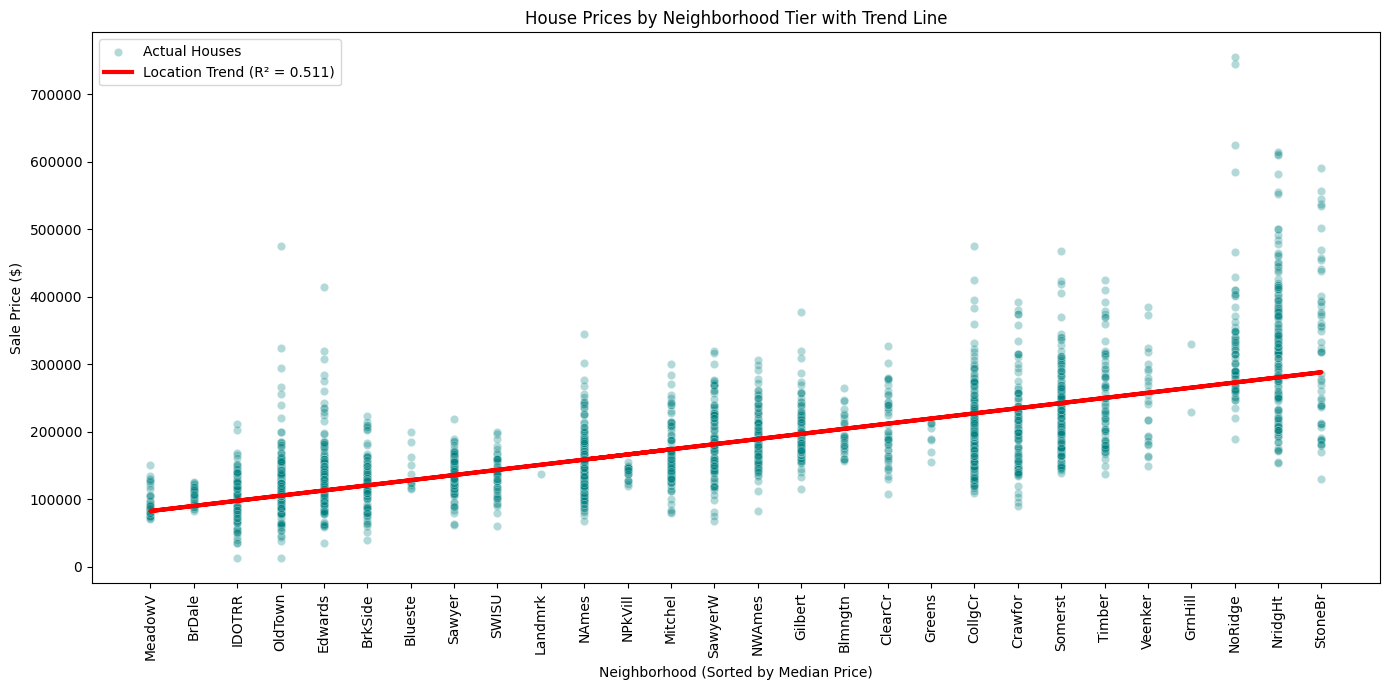

Location (Neighborhood) alone explains 51.1% of the house price variance.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Prepare data: Rank neighborhoods by median SalePrice
nb_rank = df_cleaned.groupby('Neighborhood')['SalePrice'].median().sort_values()
nb_map = {name: i for i, name in enumerate(nb_rank.index)}
df_cleaned['Nb_Rank'] = df_cleaned['Neighborhood'].map(nb_map)

# 2. Fit linear model for the trend
X_nb = df_cleaned[['Nb_Rank']].values
y_nb = df_cleaned['SalePrice'].values
model_nb = LinearRegression().fit(X_nb, y_nb)
line_nb = model_nb.predict(X_nb)
r2_nb = model_nb.score(X_nb, y_nb)

# 3. Plotting
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df_cleaned, x='Nb_Rank', y='SalePrice', alpha=0.3, color='teal', label='Actual Houses')
plt.plot(df_cleaned['Nb_Rank'], line_nb, color='red', linewidth=3, label=f'Location Trend (R² = {r2_nb:.3f})')

# Formatting the X-axis to show neighborhood names instead of ranks
plt.xticks(ticks=range(len(nb_rank)), labels=nb_rank.index, rotation=90)
plt.title('House Prices by Neighborhood Tier with Trend Line')
plt.xlabel('Neighborhood (Sorted by Median Price)')
plt.ylabel('Sale Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Location (Neighborhood) alone explains {r2_nb*100:.1f}% of the house price variance.")

**Observations:**
*   **Neighborhoods:** There is a clear hierarchy. Neighborhoods like *Stone Brook* and *Northridge Heights* represent the luxury tier, while *Old Town* and *Iowa DOT and Rail Road* serve the entry-level market.
*   **Age:** There is a strong negative correlation; newer homes (low HouseAge) consistently command higher prices, with the 'price ceiling' dropping significantly as homes pass the 20-30 year mark unless they have been remodeled.